# Phase 2: Factually Grounded RAG

## Exercise

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json

from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

In [3]:
# Get results from phase 1
with open("outputs/phase1_outputs/retrieved_docs_knn.json", "r", encoding="utf-8") as f:
    phase1_results = json.load(f)

In [4]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    output_attentions=True
)

model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### Positional Embeddings

In [5]:
word = "medicine"
text = " ".join([word] * 200)

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=202  # CLS + 200 tokens + SEP
)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(tokens[:10], "...", tokens[-10:])

['[CLS]', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine'] ... ['medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', '[SEP]']


In [6]:
with torch.no_grad():
    position_embeddings = model.embeddings.position_embeddings.weight

# positions for the real token sequence
seq_len = inputs["input_ids"].shape[1]
pos_embs = position_embeddings[:seq_len].detach().cpu().numpy()

# remove CLS and SEP
token_pos_embs = pos_embs[1:-1]
token_labels = tokens[1:-1]

print(token_pos_embs.shape)

(200, 768)


#### 2a.Distance to first token

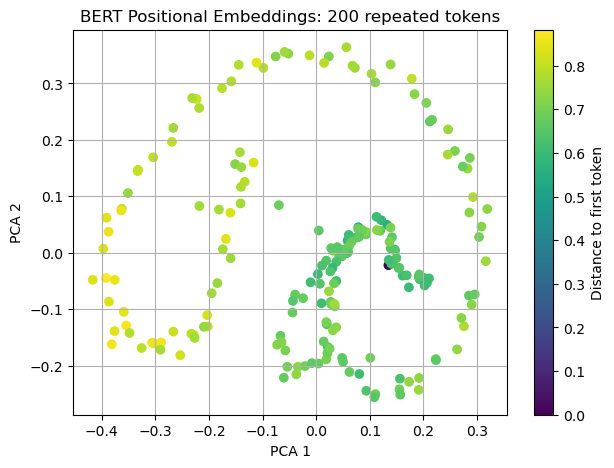

In [7]:
dist_to_first = np.linalg.norm(token_pos_embs - token_pos_embs[0], axis=1)

pca = PCA(n_components=2)
pos_2d = pca.fit_transform(token_pos_embs)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pos_2d[:, 0],
    pos_2d[:, 1],
    c=dist_to_first
)
plt.colorbar(scatter, label="Distance to first token")
plt.title("BERT Positional Embeddings: 200 repeated tokens")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

#### 2b. Distance matrix

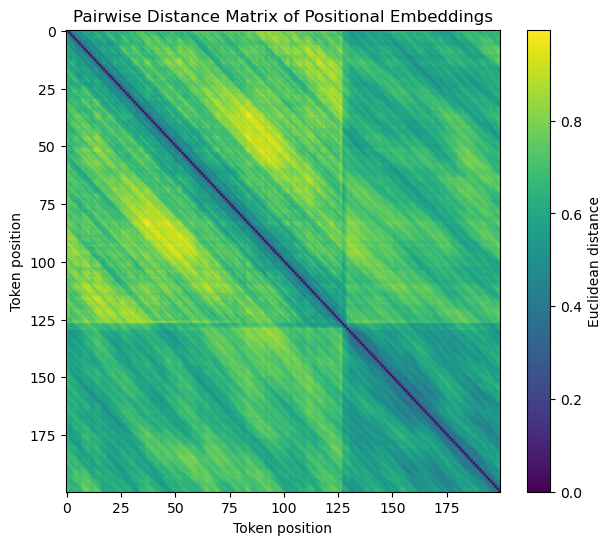

In [8]:
dist_matrix = pairwise_distances(token_pos_embs, metric="euclidean")

plt.figure(figsize=(7, 6))
plt.imshow(dist_matrix, aspect="auto")
plt.colorbar(label="Euclidean distance")
plt.title("Pairwise Distance Matrix of Positional Embeddings")
plt.xlabel("Token position")
plt.ylabel("Token position")
plt.show()

### Contextual embeddings from layer 0 to 11

In [9]:
text = "Sleep apnea can be improved by weight loss, avoiding alcohol, and positional therapy."

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

hidden_states = outputs.hidden_states
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Number of layers:", len(hidden_states))
print(tokens)

Number of layers: 13
['[CLS]', 'sleep', 'ap', '##nea', 'can', 'be', 'improved', 'by', 'weight', 'loss', ',', 'avoiding', 'alcohol', ',', 'and', 'position', '##al', 'therapy', '.', '[SEP]']


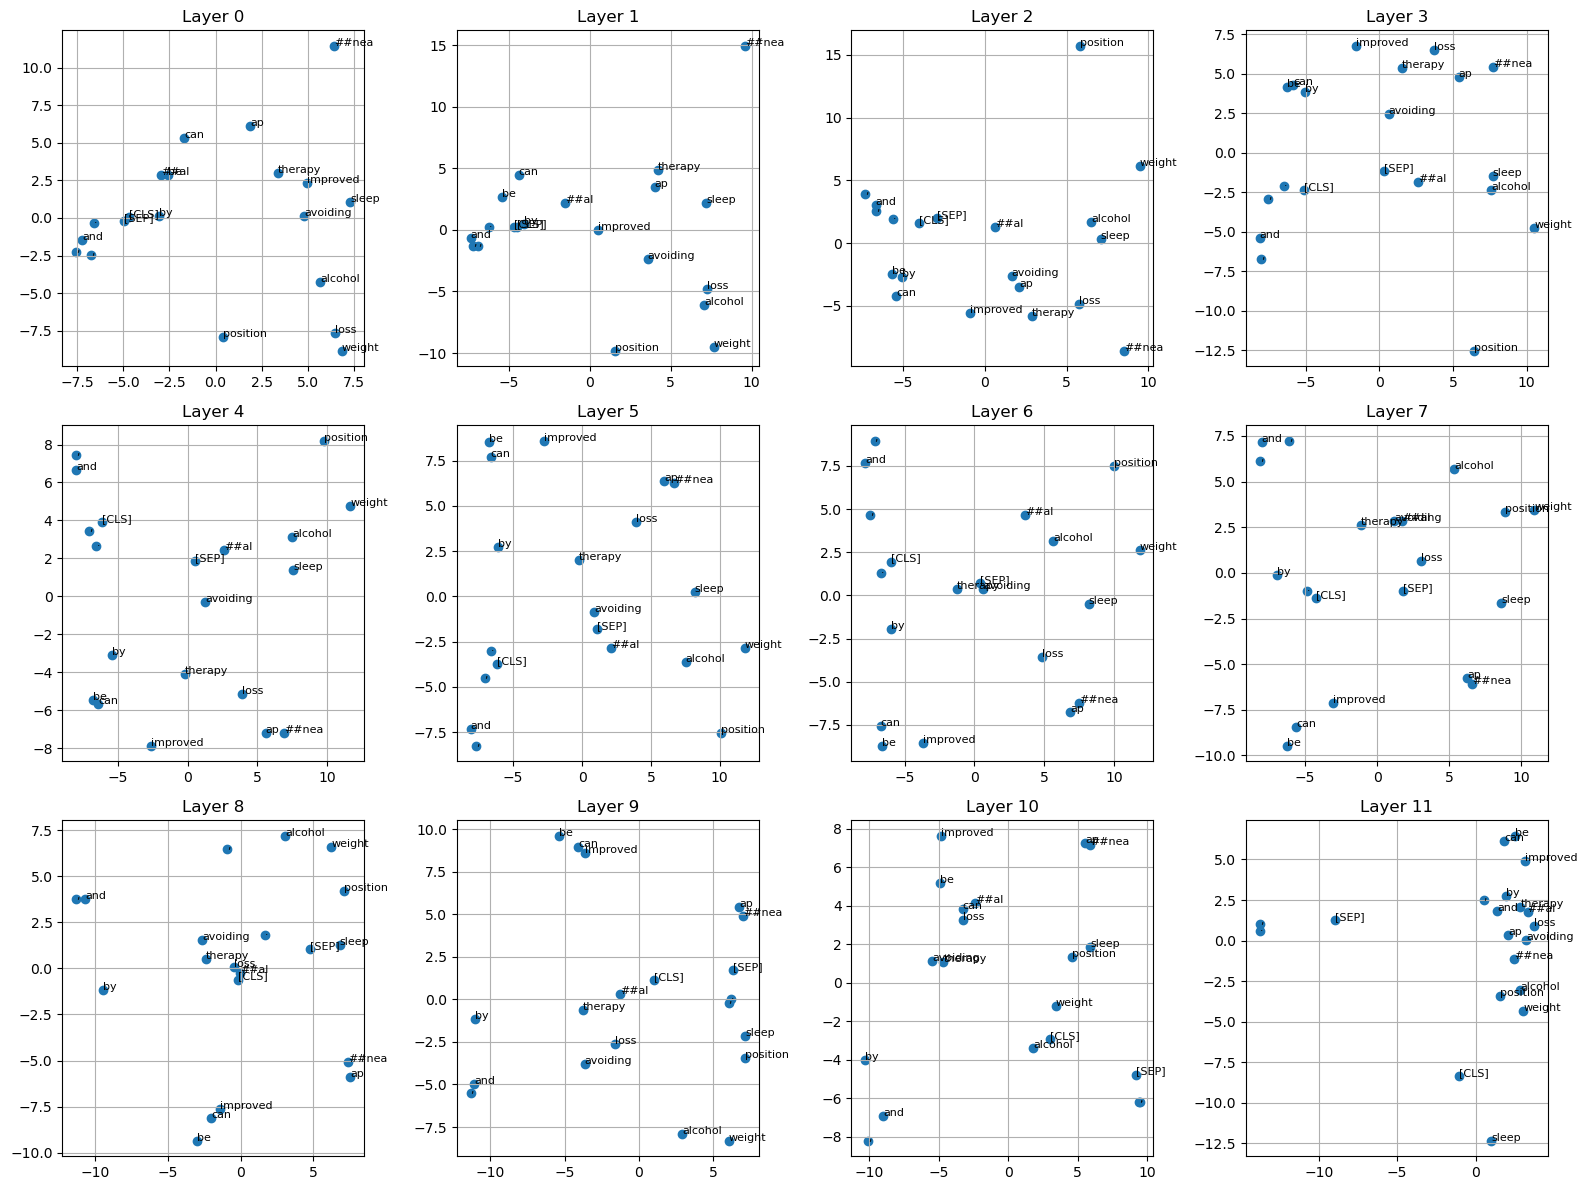

In [10]:
layers = hidden_states[1:]  # 12 BERT layers

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for layer_idx, layer_tensor in enumerate(layers):
    emb = layer_tensor[0].detach().cpu().numpy()

    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb)

    ax = axes[layer_idx]
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1])

    for i, token in enumerate(tokens):
        ax.annotate(token, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=8)

    ax.set_title(f"Layer {layer_idx}")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Self-attention Visualization

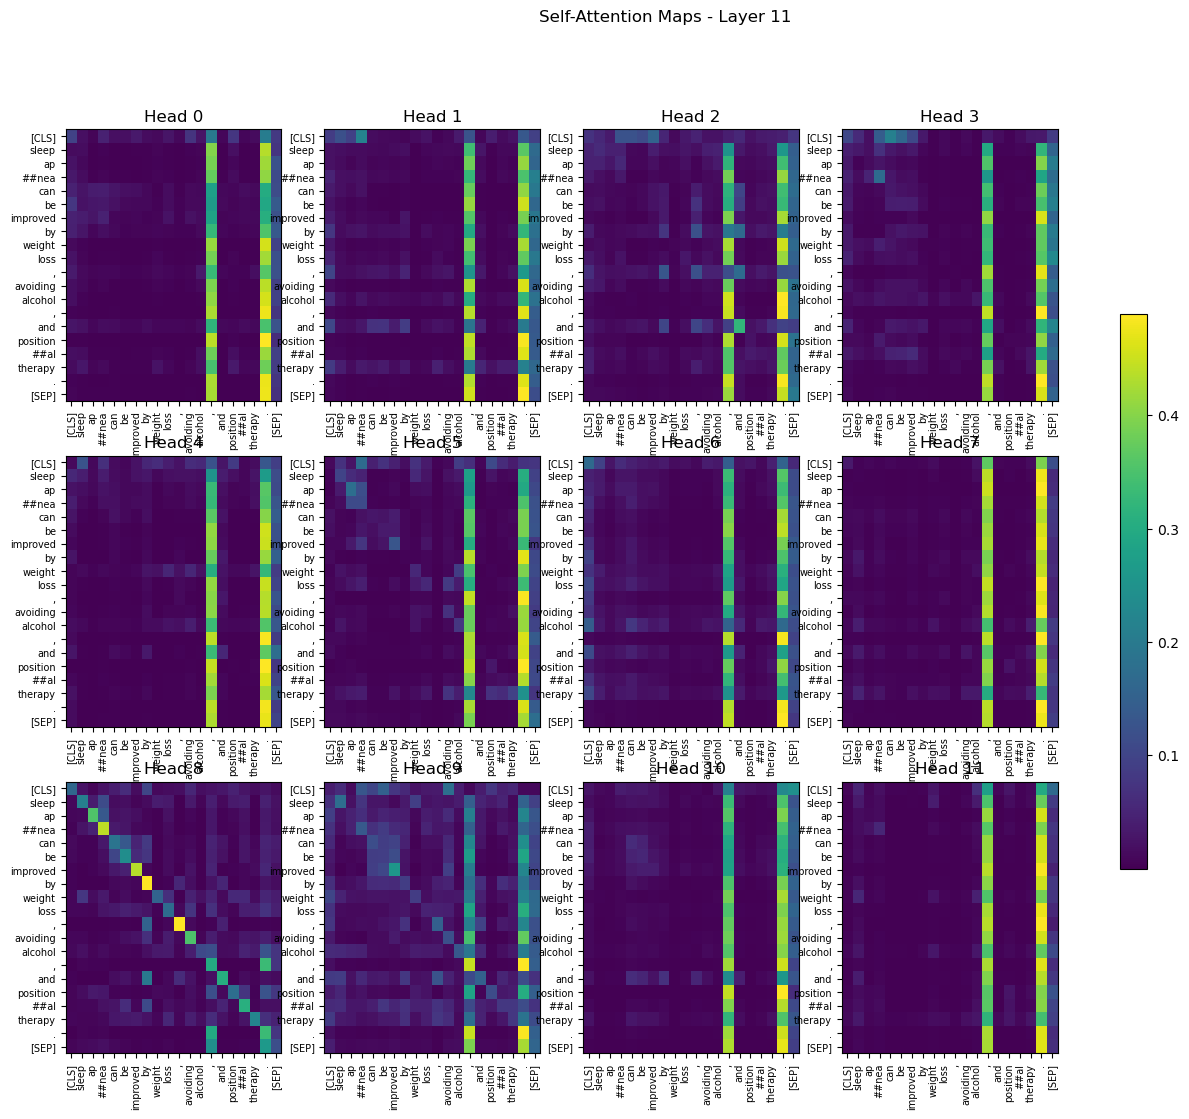

In [11]:
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

layer_idx = 11
attention_layer = attentions[layer_idx][0].detach().cpu().numpy()

num_heads = attention_layer.shape[0]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for head in range(num_heads):
    ax = axes[head]
    im = ax.imshow(attention_layer[head], aspect="auto")

    ax.set_title(f"Head {head}")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)

fig.colorbar(im, ax=axes.tolist(), shrink=0.6)
plt.suptitle(f"Self-Attention Maps - Layer {layer_idx}")
plt.show()

In [37]:
# ============================================================
# PHASE 2 — Configuration
# ============================================================

from pathlib import Path
from helpers import load_corpus_txt

PHASE2_OUTPUT_DIR = Path("outputs/phase2_outputs")
PHASE2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open("outputs/phase1_outputs/retrieved_docs_knn.json", "r", encoding="utf-8") as f:
    phase1_knn_outputs = json.load(f)
  
docs = load_corpus_txt("./BioGen2024/filtered_pubmed_abstracts.txt")  
doc_by_pmid = {doc["pmid"]: doc for doc in docs}

BEST_RUN_RESULTS = {}
BEST_QUERIES = {}

for qid, item in phase1_knn_outputs.items():
    BEST_QUERIES[qid] = item["query"]

    results = []
    for r in item["results"]:
        pmid = r["pmid"]
        score = r["score"]
        results.append((pmid, score))

    BEST_RUN_RESULTS[qid] = results

TOP_K_DOCS = 3
TOP_SENTENCES_PER_DOC = 3

REFERENCE_SENTENCES_PATH = PHASE2_OUTPUT_DIR / "phase2_reference_sentences.json"
GENERATED_ANSWERS_PATH = PHASE2_OUTPUT_DIR / "phase2_generated_answers.json"
JUDGE_RESULTS_PATH = PHASE2_OUTPUT_DIR / "phase2_judge_results.json"

In [38]:
# ============================================================
# Load biomedical cross-encoder for sentence selection
# ============================================================

from sentence_transformers import CrossEncoder
from helpers import generate_answer

CROSS_ENCODER_MODEL = "ncbi/MedCPT-Cross-Encoder"

cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [39]:
# ============================================================
# Sentence splitting helper
# ============================================================

import re

def split_abstract_into_sentences(text):
    if not text:
        return []

    text = re.sub(r"\s+", " ", text.strip())

    # Simple biomedical-safe sentence splitter
    sentences = re.split(r"(?<=[.!?])\s+", text)

    # Remove very short or empty sentences
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]

    return sentences

In [48]:
# # ============================================================
# # Sentence selection strategy
# # ============================================================

from tqdm import tqdm

def select_reference_sentences_for_query(
    qid,
    query_text,
    retrieved_docs,
    doc_by_pmid,
    top_k_docs=3,
    top_sentences_per_doc=3
):
    query_results = []

    top_docs = retrieved_docs[:top_k_docs]

    for rank, item in enumerate(top_docs, start=1):
        pmid = str(item[0])
        retrieval_score = float(item[1])

        if pmid not in doc_by_pmid:
            continue

        doc = doc_by_pmid[pmid]
        title = doc.get("title", "")
        abstract = doc.get("abstract", "")

        sentences = split_abstract_into_sentences(abstract)

        if not sentences:
            continue

        pairs = [(query_text, sent) for sent in sentences]
        scores = cross_encoder.predict(pairs)

        scored_sentences = []
        for sent, score in zip(sentences, scores):
            scored_sentences.append({
                "sentence": sent,
                "cross_encoder_score": float(score)
            })

        scored_sentences = sorted(
            scored_sentences,
            key=lambda x: x["cross_encoder_score"],
            reverse=True
        )

        selected = scored_sentences[:top_sentences_per_doc]

        query_results.append({
            "qid": qid,
            "query": query_text,
            "pmid": pmid,
            "doc_rank": rank,
            "retrieval_score": retrieval_score,
            "title": title,
            "selected_sentences": selected
        })

    return query_results

In [49]:
# # ============================================================
# # Run Phase 2 sentence selection
# # ============================================================

phase2_reference_sentences = {}

for qid, query_text in tqdm(BEST_QUERIES.items(), desc="Selecting reference sentences"):
    phase2_reference_sentences[qid] = select_reference_sentences_for_query(
        qid=qid,
        query_text=query_text,
        retrieved_docs=BEST_RUN_RESULTS[qid],
        doc_by_pmid=doc_by_pmid,
        top_k_docs=TOP_K_DOCS,
        top_sentences_per_doc=TOP_SENTENCES_PER_DOC
    )

with open(REFERENCE_SENTENCES_PATH, "w", encoding="utf-8") as f:
    json.dump(phase2_reference_sentences, f, indent=2, ensure_ascii=False)

print("Saved:", REFERENCE_SENTENCES_PATH)

Selecting reference sentences: 100%|██████████| 33/33 [00:07<00:00,  4.43it/s]

Saved: outputs\phase2_outputs\phase2_reference_sentences.json


In [50]:
# ============================================================
# Inspect selected reference sentences
# ============================================================

example_qid = next(iter(phase2_reference_sentences))

print("QID:", example_qid)
print("Query:", BEST_QUERIES[example_qid])

for doc in phase2_reference_sentences[example_qid]:
    print("\nPMID:", doc["pmid"])
    print("Title:", doc["title"])
    for s in doc["selected_sentences"]:
        print(f"- Score {s['cross_encoder_score']:.4f}: {s['sentence']}")

QID: 116
Query: natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.

PMID: 22014867
Title: Lifestyle modifications and the resolution of obstructive sleep apnea syndrome: a case report.
- Score 1.0000: This purpose of this case study is to describe a natural method to help in management of obstructive sleep apnea syndrome (OSAS), which is known to be a common and debilitating condition.

PMID: 37532368
Title: Integrative Approach to Managing Obstructive Sleep Apnea.
- Score 1.0000: Complementary and integrative approaches to OSA management are varied and, in conjunction with conventional methods, may offer some reduction in the apnea-hypopnea index.
- Score 0.9990: Conventional therapies for obstructive sleep apnea (OSA), including CPAP and oral appliances, offer the best opportunity for symptomatic improvement and reduction in OSA overall health impact.
- Score 0.5

In [51]:
import os
import sys

google_colab = "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT")

if google_colab:
    # Use secret if running in Google Colab
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    # Store Hugging Face data under `/content` if running in Colab Enterprise
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    # Authenticate with Hugging Face
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

In [52]:
# ============================================================
# Load answer generation model
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# DECODER_MODEL = "google/gemma-2-2b-it"
DECODER_MODEL = "google/medgemma-4b-it"
# DECODER_MODEL = "google/gemma-2-2b-it"
# DECODER_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(DECODER_MODEL)

decoder_model = AutoModelForCausalLM.from_pretrained(
    DECODER_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

Current model requires 34818 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


In [53]:
# ============================================================
# Generate Phase 2 answers
# ============================================================

if GENERATED_ANSWERS_PATH.exists():
    print("File already exists. Loading existing answers...")

    with open(GENERATED_ANSWERS_PATH, "r", encoding="utf-8") as f:
        phase2_generated_answers = json.load(f)

else:
    print("Generating answers...")

    phase2_generated_answers = {}

    for qid, reference_docs in tqdm(phase2_reference_sentences.items(), desc="Generating answers"):
        
        question = BEST_QUERIES[qid]

        answer = generate_answer(
            question=question,
            reference_docs=reference_docs,
        )

        phase2_generated_answers[qid] = {
            "qid": qid,
            "question": question,
            "answer": answer,
            "references": reference_docs
        }

    with open(GENERATED_ANSWERS_PATH, "w", encoding="utf-8") as f:
        json.dump(phase2_generated_answers, f, indent=2, ensure_ascii=False)

    print("Saved:", GENERATED_ANSWERS_PATH)

File already exists. Loading existing answers...


In [54]:
# ============================================================
# IAedu GPT-4o judge setup
# ============================================================

import os
import requests

IAEDU_API_KEY = os.getenv("IAEDU_API_KEY")
IAEDU_API_URL = os.getenv("IAEDU_API_URL")

IAEDU_CHANNEL_ID = "cmoh3pa5o286kj301ga04tio8"
IAEDU_THREAD_ID = "NE8WdwFO2kQms7fQ3upjk"

def clean_judge_label(text):
    text = str(text).strip()
    text = text.replace("'", "").replace('"', "").strip()
    
    valid_labels = [
        "Required",
        "Unnecessary",
        "Borderline",
        "Inappropriate",
        "Unsupported",
        "Partially Supported",
        "Supported"
    ]
    
    for label in valid_labels:
        if label.lower() == text.lower():
            return label
    
    for label in valid_labels:
        if label.lower() in text.lower():
            return label
    
    return text

def call_iaedu_judge(prompt):
    headers = {
        "x-api-key": IAEDU_API_KEY
    }

    data = {
        "channel_id": IAEDU_CHANNEL_ID,
        "thread_id": IAEDU_THREAD_ID,
        "user_info": "{}",
        "message": prompt
    }

    response = requests.post(
        IAEDU_API_URL,
        headers=headers,
        data=data,
        timeout=60,
        stream=True
    )

    response.raise_for_status()

    final_content = None
    token_content = []

    for line in response.iter_lines(decode_unicode=True):
        if not line:
            continue

        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue

        if obj.get("type") == "token":
            token_content.append(obj.get("content", ""))

        elif obj.get("type") == "message":
            content = obj.get("content", {})

            if isinstance(content, dict):
                final_content = content.get("content")
            else:
                final_content = content

    if final_content is None:
        final_content = "".join(token_content)

    return clean_judge_label(final_content)

In [55]:
test_prompt = """
Respond ONLY with one label from this list:
['Required', 'Unnecessary', 'Borderline', 'Inappropriate']

Question: Can exercise improve sleep?
Answer sentence: Exercise may improve sleep quality in some adults.

Label:
"""

print(call_iaedu_judge(test_prompt))

In [56]:
# ============================================================
# LLM judge: reference sentence alignment
# ============================================================

def build_sentence_alignment_prompt(question, answer_sentence):
    return f"""
You are an expert annotator. Given a question and an answer sentence, your task is to assign
a single label from the following list: ['Required', 'Unnecessary', 'Borderline', 'Inappropriate'].

Label definitions:
Required: The answer sentence is necessary to have in the generated answer for completeness.
Unnecessary: The answer sentence is not required. It may be trivial, overloaded, only recommends seeing a professional, or irrelevant.
Borderline: The sentence is relevant and possibly useful, but not required.
Inappropriate: The assertion may harm the patient.

Question:
{question}

Answer sentence:
{answer_sentence}

Respond ONLY with the label. No explanation.
""".strip()

In [57]:
# ============================================================
# LLM judge: answer entailment
# ============================================================

def build_entailment_prompt(question, answer, reference_context):
    return f"""
You are an expert biomedical annotator. Given a question, a complete answer, and its reference
sentences, assign a single label from the following list:
['Unsupported', 'Partially Supported', 'Supported'].

Label definitions:
Supported: The answer is completely supported by the reference sentences.
Partially Supported: The answer is relevant and partially supported by the reference sentences, possibly even “good to know”.
Unsupported: The answer is not supported by the provided sentences or may harm the patient.

Question:
{question}

Complete answer:
{answer}

Reference sentences:
{reference_context}

Respond ONLY with the label. No explanation.
""".strip()

In [58]:
# ============================================================
# Run LLM judge evaluation only if file does not exist
# ============================================================

from helpers import build_reference_context
import time

if JUDGE_RESULTS_PATH.exists():
    print("Judge results file already exists. Loading existing results...")

    with open(JUDGE_RESULTS_PATH, "r", encoding="utf-8") as f:
        phase2_judge_results = json.load(f)

else:
    print("Judge results file not found. Running LLM judge evaluation...")

    phase2_judge_results = {}

    for qid, item in tqdm(phase2_generated_answers.items(), desc="Judging answers"):
        
        question = item["question"]
        answer = item["answer"]
        reference_docs = item["references"]

        reference_context = build_reference_context(reference_docs)

        # Judge selected reference sentences
        sentence_judgments = []

        for doc in reference_docs:
            pmid = doc["pmid"]

            for sent_obj in doc["selected_sentences"]:
                sent = sent_obj["sentence"]

                prompt = build_sentence_alignment_prompt(question, sent)
                label = call_iaedu_judge(prompt)
                time.sleep(1)

                sentence_judgments.append({
                    "pmid": pmid,
                    "sentence": sent,
                    "cross_encoder_score": sent_obj["cross_encoder_score"],
                    "judge_label": label
                })

        # Judge final answer entailment
        entailment_prompt = build_entailment_prompt(
            question=question,
            answer=answer,
            reference_context=reference_context
        )

        entailment_label = call_iaedu_judge(entailment_prompt)
        time.sleep(1)

        phase2_judge_results[qid] = {
            "qid": qid,
            "question": question,
            "answer": answer,
            "sentence_judgments": sentence_judgments,
            "entailment_label": entailment_label
        }

    with open(JUDGE_RESULTS_PATH, "w", encoding="utf-8") as f:
        json.dump(phase2_judge_results, f, indent=2, ensure_ascii=False)

    print("Saved:", JUDGE_RESULTS_PATH)

Judge results file already exists. Loading existing results...


In [59]:
# ============================================================
# Summary tables for report
# ============================================================
import pandas as pd

rows = []

for qid, item in phase2_judge_results.items():
    labels = [x["judge_label"] for x in item["sentence_judgments"]]

    rows.append({
        "qid": qid,
        "entailment_label": item["entailment_label"],
        "required_sentences": labels.count("Required"),
        "borderline_sentences": labels.count("Borderline"),
        "unnecessary_sentences": labels.count("Unnecessary"),
        "inappropriate_sentences": labels.count("Inappropriate"),
        "total_reference_sentences": len(labels)
    })

phase2_summary_df = pd.DataFrame(rows)
phase2_summary_df

,qid,entailment_label,required_sentences,borderline_sentences,unnecessary_sentences,inappropriate_sentences,total_reference_sentences
0,116,Supported,1,2,2,0,7
1,118,Partially Supported,2,3,4,0,9
2,120,Partially Supported,0,1,3,0,7
3,122,Partially Supported,1,2,2,0,9
4,124,,0,0,5,0,5
5,126,,1,0,2,0,7
6,128,Partially Supported,1,1,3,0,8
7,130,Supported,3,1,3,0,7
8,132,Supported,3,4,1,0,8
9,134,Supported,3,0,6,0,9


In [60]:
# ============================================================
# Aggregate judge statistics
# ============================================================

print("Entailment labels:")
display(phase2_summary_df["entailment_label"].value_counts())

print("\nReference sentence labels:")
sentence_labels = []

for item in phase2_judge_results.values():
    for s in item["sentence_judgments"]:
        sentence_labels.append(s["judge_label"])

display(pd.Series(sentence_labels).value_counts())

Entailment labels:


entailment_label
                       22
Partially Supported     7
Supported               4
Name: count, dtype: int64


Reference sentence labels:


               162
Unnecessary     52
Required        23
Borderline      19
Name: count, dtype: int64

In [61]:
# ============================================================
# Inspect Phase 2 quality manually
# ============================================================

for qid, item in list(phase2_judge_results.items())[:5]:
    print("=" * 150)
    print("QID:", qid)
    print("QUESTION:", item["question"])
    
    print("\nSELECTED SENTENCES:")
    for s in item["sentence_judgments"]:
        print(f"\nPMID: {s['pmid']}")
        print(f"Cross-encoder score: {s['cross_encoder_score']:.4f}")
        print(f"Judge label: {s['judge_label']}")
        print("Sentence:", s["sentence"])
    
    print("\nGENERATED ANSWER:")
    print(item["answer"])
    
    print("\nENTAILMENT LABEL:", item["entailment_label"])

QID: 116
QUESTION: natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.

SELECTED SENTENCES:

PMID: 22014867
Cross-encoder score: 1.0000
Judge label: 
Sentence: This purpose of this case study is to describe a natural method to help in management of obstructive sleep apnea syndrome (OSAS), which is known to be a common and debilitating condition.

PMID: 37532368
Cross-encoder score: 1.0000
Judge label: Borderline
Sentence: Complementary and integrative approaches to OSA management are varied and, in conjunction with conventional methods, may offer some reduction in the apnea-hypopnea index.

PMID: 37532368
Cross-encoder score: 0.9990
Judge label: Unnecessary
Sentence: Conventional therapies for obstructive sleep apnea (OSA), including CPAP and oral appliances, offer the best opportunity for symptomatic improvement and reduction in OSA overall health impact.

PMID: 37

In [62]:
# ============================================================
# Phase 2 summary statistics
# ============================================================

sentence_labels = []
entailment_labels = []

for item in phase2_judge_results.values():
    entailment_labels.append(item["entailment_label"])

    for s in item["sentence_judgments"]:
        sentence_labels.append(s["judge_label"])

print("Sentence selection labels:")
display(pd.Series(sentence_labels).value_counts())

print("\nAnswer entailment labels:")
display(pd.Series(entailment_labels).value_counts())

Sentence selection labels:


               162
Unnecessary     52
Required        23
Borderline      19
Name: count, dtype: int64


Answer entailment labels:


                       22
Partially Supported     7
Supported               4
Name: count, dtype: int64